In [ ]:
"""
Boring Bar Optimization — Cavity Geometry + Independent Absorber Dimensions
============================================================================
Design variables (4):
  x1 = D_cav   : cavity bore diameter  [m]  (10–34 mm)
  x2 = L_cav   : cavity length         [m]  (20–170 mm)
  x3 = D_abs   : absorber diameter     [m]  (≤ D_cav)
  x4 = L_abs   : absorber length       [m]  (≤ L_cav)

Hard constraint:
  absorber volume ≤ 0.70 × cavity volume
  i.e.  π*(D_abs/2)²*L_abs  ≤  0.70 * π*(D_cav/2)²*L_cav

Approach:
  For each (D_cav, L_cav) cavity point on a coarse grid (6×6),
  sweep absorber fill fraction φ = V_abs/V_cav ∈ [0.1, 0.70] (5 pts)
  and absorber aspect r = (D_abs/D_cav) ∈ [0.3, 1.0] (5 pts)
  → L_abs = φ * (D_cav/D_abs)² * L_cav
  → Total evaluations: 6×6×5×5 = 900 (fast via modal FRF)

3 Objectives:
  f1 = max  mean alim      [mm]
  f2 = max  static stiffness [MN/m]
  f3 = min  total mass     [kg]

Absorber tuning: kd and cd optimised for each design via Den Hartog + refinement.
"""

import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size':9,'axes.titlesize':9,'axes.labelsize':8.5,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'legend.fontsize':7,'figure.dpi':150})

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1. FIXED PARAMETERS
# ══════════════════════════════════════════════════════════════
E_body   = 280e9
rho_body = 7850.0 * 1.2    # 9420 kg/m³  WC-composite
rho_tc   = 15600.0         # TC absorber
zeta_s   = 0.01            # structural damping

L_total  = 0.300
D1_out   = 0.060
D_main   = 0.040

# Body through-bore (Sec1-3): 50% of local outer diameter
D_body_in1 = D1_out * 0.50    # 30 mm
D_body_in3 = D_main * 0.50    # 20 mm

L1 = 0.050; L2 = 0.040       # Sec1, Sec2 fixed lengths
L5_tip = 0.030                # fixed solid tip

Z_TIP = L5_tip                # cavity always starts 30mm from free end

# Cutting: boring, single-point, full 360°
Nt=1; Ktc=2000e6; Krc=800e6; ratio_kr=Krc/Ktc

N_ELEM = 60; N_MODES = 6

# Design variable bounds
D_cav_min, D_cav_max = 0.010, D_main - 2*0.003   # 10–34 mm
L_cav_min, L_cav_max = 0.020, 0.170               # 20–170 mm
VOL_FRAC_MAX = 0.70                                # hard constraint

print("="*62)
print("Boring Bar v5 — 4 Design Variables (Cavity + Absorber dims)")
print("="*62)
print(f"  Cavity  D: {D_cav_min*1e3:.0f}–{D_cav_max*1e3:.0f} mm   "
      f"L: {L_cav_min*1e3:.0f}–{L_cav_max*1e3:.0f} mm")
print(f"  Absorber fills ≤ {VOL_FRAC_MAX*100:.0f}% cavity volume")
print(f"  Body bore: D_in1={D_body_in1*1e3:.0f}mm  D_in3={D_body_in3*1e3:.0f}mm")
print("="*62)

Boring Bar v5 — 4 Design Variables (Cavity + Absorber dims)
  Cavity  D: 10–34 mm   L: 20–170 mm
  Absorber fills ≤ 70% cavity volume
  Body bore: D_in1=30mm  D_in3=20mm


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. CROSS-SECTION
#    Sec1: hollow 60/30mm  Sec2: hollow taper  Sec3: hollow 40/20mm
#    Sec4: cavity bore D_cav  Sec5: solid 40mm
# ══════════════════════════════════════════════════════════════════════════════
def xsec(z, D_cav, L_cav):
    """Compute section properties at axial coordinate z.

    Returns:
      A, I, Ip          : area, second moment, polar moment
      rho_body*A, rho_body*I, rho_body*Ip : mass-related quantities

    This is used by FEM assembly and static mass integration to describe
    the rotating boring-bar geometry with a variable cavity region.
    """
    z_cav = L_total - Z_TIP - L_cav
    z2 = L1+L2; z4 = z_cav+L_cav
    if   z < L1:  Ro = D1_out/2
    elif z < z2:  Ro = D1_out/2 + (z-L1)/L2*(D_main-D1_out)/2
    else:         Ro = D_main/2
    if z < L1:
        Ri = D_body_in1/2
    elif z < z2:
        t = (z-L1)/L2
        Ri = D_body_in1/2 + t*(D_body_in3/2 - D_body_in1/2)
    elif z < z_cav:
        Ri = D_body_in3/2
    elif z < z4:
        Ri = D_cav/2
    else:
        Ri = 0.0
    Ri = np.clip(Ri, 0.0, Ro-1e-4)
    A  = np.pi*(Ro**2-Ri**2); I  = np.pi*(Ro**4-Ri**4)/4
    Ip = np.pi*(Ro**4-Ri**4)/2
    return A, I, Ip, rho_body*A, rho_body*I, rho_body*Ip

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. FEM
# ══════════════════════════════════════════════════════════════════════════════
gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
gw = np.array([5/9, 8/9, 5/9])

def build_MK(D_cav, L_cav):
    """Assemble global mass and stiffness matrices for the bar.

    Uses 2-node beam elements with 3-point Gauss quadrature.
    The returned matrices are reduced to free DOFs by removing the fixed end.
    """
    ne=N_ELEM; nn=ne+1; le=L_total/ne
    zn=np.linspace(0,L_total,nn); dof=2*nn
    Mg=np.zeros((dof,dof)); Kg=np.zeros((dof,dof)); Gg=np.zeros((dof,dof))
    for e in range(ne):
        za=zn[e]; Ke=np.zeros((4,4)); Me=np.zeros((4,4)); Ge=np.zeros((4,4))
        for g,w in zip(gp,gw):
            xi=(g+1)/2; zg=za+xi*le
            _,Ig,Ipg,rhoAg,rhoIg,rhoIpg = xsec(zg,D_cav,L_cav)
            N1=1-3*xi**2+2*xi**3; N2=le*(xi-2*xi**2+xi**3)
            N3=3*xi**2-2*xi**3;   N4=le*(-xi**2+xi**3)
            dN1=(-6*xi+6*xi**2)/le; dN2=1-4*xi+3*xi**2
            dN3=(6*xi-6*xi**2)/le;  dN4=-2*xi+3*xi**2
            d2N1=(-6+12*xi)/le**2;  d2N2=(-4+6*xi)/le
            d2N3=(6-12*xi)/le**2;   d2N4=(-2+6*xi)/le
            Nv=np.array([N1,N2,N3,N4]); dN_=np.array([dN1,dN2,dN3,dN4])
            d2N=np.array([d2N1,d2N2,d2N3,d2N4]); fac=le*w/2
            Ke+=E_body*Ig*np.outer(d2N,d2N)*fac
            Me+=(rhoAg*np.outer(Nv,Nv)+rhoIg*np.outer(dN_,dN_))*fac
            Ge+=rhoIpg*np.outer(dN_,dN_)*fac
        idx=[2*e,2*e+1,2*(e+1),2*(e+1)+1]
        for i,ii in enumerate(idx):
            for j,jj in enumerate(idx):
                Mg[ii,jj]+=Me[i,j]; Kg[ii,jj]+=Ke[i,j]; Gg[ii,jj]+=Ge[i,j]
    free=list(range(2,dof)); sl=np.ix_(free,free)
    return Mg[sl],Kg[sl],Gg[sl],Mg[sl]

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. MODAL REDUCTION
# ══════════════════════════════════════════════════════════════════════════════
def modal_reduce(D_cav, L_cav):
    """Compute a reduced modal model for the cavity geometry.

    Returns natural frequencies, modal shapes, gyroscopic and mass projections,
    plus tip displacement shape for FRF forcing.
    This model is reused in the main sweep to avoid repeated full FEM solves.
    """
    Mf,Kf,Gf,Mcf = build_MK(D_cav,L_cav)
    evals,evecs = eigh(Kf,Mf,subset_by_index=[0,N_MODES-1])
    wn = np.sqrt(np.maximum(evals,0))
    sc = np.sqrt(np.diag(evecs.T@Mf@evecs))
    Phi = evecs/sc
    return dict(wn=wn, Phi=Phi, Gm=Phi.T@Gf@Phi, Mcm=Phi.T@Mcf@Phi,
                tip=Phi[2*(N_ELEM-1),:], Cm=2*zeta_s*wn, Mf=Mf, Kf=Kf)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. ABSORBER PARAMETERS  (now independent D_abs, L_abs)
# ══════════════════════════════════════════════════════════════════════════════
def absorber_params(D_cav, L_cav, D_abs, L_abs):
    """Compute absorber mass and axial position inside the cavity.

    The absorber is modelled as a solid cylinder centred axially in the cavity.
    """
    md  = rho_tc * np.pi*(D_abs/2)**2 * L_abs
    z_cav = L_total - Z_TIP - L_cav
    z_d = z_cav + L_cav/2     # absorber centred in cavity
    return md, z_d

def vol_fraction(D_cav, L_cav, D_abs, L_abs):
    """Return absorber volume fraction relative to cavity volume."""
    V_abs = np.pi*(D_abs/2)**2*L_abs
    V_cav = np.pi*(D_cav/2)**2*L_cav
    return V_abs / (V_cav + 1e-20)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. MODAL FRF
# ══════════════════════════════════════════════════════════════════════════════
def frf(modal, freqs_hz, Omega, D_cav, L_cav, D_abs, L_abs, kd=0.0, cd=0.0):
    """Compute frequency response functions for the reduced modal model.

    Builds the dynamic impedance matrix in modal coordinates including gyroscopic
    coupling and optional absorber attachment. Returns direct and cross FRFs.
    """
    N=N_MODES; wn=modal['wn']; tip=modal['tip']
    Gm=modal['Gm']; Cm_d=modal['Cm']
    Km_eff = np.diag(wn**2) - Omega**2*modal['Mcm']

    md, z_d = absorber_params(D_cav, L_cav, D_abs, L_abs)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]

    n2=2*N; use_abs=(kd>0); na=n2+2 if use_abs else n2
    Hxx=np.zeros(len(freqs_hz),dtype=complex)
    Hxy=np.zeros(len(freqs_hz),dtype=complex)

    for k,f in enumerate(freqs_hz):
        w=2*np.pi*f; w2=w**2
        Z=np.zeros((na,na),dtype=complex)
        for r in range(N):
            d=-w2+1j*w*Cm_d[r]+Km_eff[r,r]
            Z[r,r]=d; Z[N+r,N+r]=d
        Z[:N,N:n2]+=2j*w*Omega*Gm
        Z[N:n2,:N]-=2j*w*Omega*Gm
        if use_abs:
            for r in range(N):
                c=(kd+1j*w*cd)*Phi_d[r]
                Z[r,r]+=Phi_d[r]*c; Z[r,n2]-=c; Z[n2,r]-=c
                Z[N+r,N+r]+=Phi_d[r]*c; Z[N+r,n2+1]-=c; Z[n2+1,N+r]-=c
            Z[n2,  n2  ]=-w2*md+kd-Omega**2*md+1j*w*cd
            Z[n2+1,n2+1]=-w2*md+kd-Omega**2*md+1j*w*cd
            Z[n2,n2+1]=2j*w*Omega*md; Z[n2+1,n2]=-2j*w*Omega*md
        fx=np.zeros(na,dtype=complex); fx[:N]=tip
        fy=np.zeros(na,dtype=complex); fy[N:n2]=tip
        try:
            sol=np.linalg.solve(Z,np.column_stack([fx,fy]))
            Hxx[k]=tip@sol[:N,0]; Hxy[k]=tip@sol[:N,1]
        except: pass
    return Hxx, Hxy

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7. DIRECTIONAL COEFFICIENTS  (boring 360°)
# ══════════════════════════════════════════════════════════════
_phi=np.linspace(0,2*np.pi,100000)
axx_b=np.trapezoid(np.sin(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
axy_b=np.trapezoid(np.cos(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
ayx_b=np.trapezoid(np.sin(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)
ayy_b=np.trapezoid(np.cos(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. STABILITY LIMIT
# ══════════════════════════════════════════════════════════════════════════════════════
def alim_from_FRF(Hxx,Hxy):
    """Estimate the cutting stability limit from frequency-domain FRFs.

    Uses 360° boring-average coefficients and the system FRF to compute the
    lowest positive depth of cut that leads to dynamic instability.
    """
    best=np.inf
    for k in range(len(Hxx)):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det),(-tr-sq)/(2*det)]:
            rl=np.real(lam)
            if rl<0:
                kap=np.imag(lam)/(rl+1e-30)
                al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
                if 0<al<best: best=al
    return min(best,0.025) if best<np.inf else 0.0

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 9. ABSORBER TUNING  (Den Hartog direct — fast)
#    kd and cd set analytically; optional 1-axis refinement
# ══════════════════════════════════════════════════════════════════════════════════════
def tune_absorber(modal, D_cav, L_cav, D_abs, L_abs, n_speeds=4):
    """Compute absorber stiffness and damping for a given absorber geometry.

    Uses Den Hartog tuning based on the first modal frequency plus a fast
    refinement search on kd. Returns optimal kd, cd, and absorber mass.
    """
    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    wn1   = modal['wn'][0]
    # Total effective mass seen by mode 1 (from modal mass = 1, M_phys)
    mu    = max(md / (rho_body*np.pi*(D_main/2)**2*L_total), 0.005)
    # Den Hartog optimal tuning
    f_opt = 1.0 / (1.0 + mu)
    z_opt = np.sqrt(3*mu / (8*(1+mu)**3))
    wd    = f_opt * wn1
    kd_dh = md * wd**2
    cd_dh = 2 * z_opt * md * wd

    # Single-axis refinement of kd only (fast: 8 evaluations)
    freqs_s = np.linspace(10, 800, 100)
    Om0     = 0.0  # tune at zero speed

    def neg_alim_kd(lkd):
        Ha,Hxa = frf(modal,freqs_s,Om0,D_cav,L_cav,D_abs,L_abs,10**lkd,cd_dh)
        Hb,Hxb = frf(modal,freqs_s,Om0,D_cav,L_cav,D_abs,L_abs,0,0)
        a=alim_from_FRF(Ha,Hxa); b=alim_from_FRF(Hb,Hxb)
        return -max(min(a,b*50),b)

    lkd0 = np.log10(kd_dh+1)
    r1 = minimize_scalar(neg_alim_kd,
                         bounds=(lkd0-1.2, lkd0+1.2),
                         method='bounded',
                         options={'xatol':0.20, 'maxiter':10})
    kd_opt = 10**r1.x
    return kd_opt, cd_dh, md

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 10. STATIC STIFFNESS + BODY MASS
# ══════════════════════════════════════════════════════════════════════════════════════
def static_stiff(D_cav, L_cav):
    """Return static stiffness at the bar tip for a given cavity geometry."""
    _,Kf,_,_=build_MK(D_cav,L_cav)
    tip_dof=2*(N_ELEM-1)
    fv=np.zeros(Kf.shape[0]); fv[tip_dof]=1.0
    return 1.0/np.linalg.solve(Kf,fv)[tip_dof]

def total_mass(D_cav, L_cav, D_abs, L_abs):
    """Compute total bar + absorber mass via numerical integration."""
    zz=np.linspace(0,L_total,2001); dz=L_total/2000
    mb=sum(rho_body*xsec(z,D_cav,L_cav)[0]*dz for z in (zz[:-1]+zz[1:])/2)
    md,_=absorber_params(D_cav,L_cav,D_abs,L_abs)
    return mb+md

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 11. STABILITY LOBE DIAGRAM
# ══════════════════════════════════════════════════════════════════════════════════════
def stability_lobes(modal, D_cav, L_cav, D_abs, L_abs, kd, cd, rpm_max=6000):
    """Compute a stability lobe diagram for a tuned absorber configuration.

    Evaluates FRFs at zero speed and extracts RPM/depth pairs where the bar
    becomes dynamically unstable. Used for producing the lobe plot in the
    results section.
    """
    freqs_c=np.linspace(10,800,300)
    Hxx,Hxy=frf(modal,freqs_c,0,D_cav,L_cav,D_abs,L_abs,kd,cd)
    speeds=[]; depths=[]
    for k,fc in enumerate(freqs_c):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det),(-tr-sq)/(2*det)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl>=0: continue
            kap=il/(rl+1e-30)
            al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
            if al<=0 or al>25: continue
            psi=np.arctan2(il,rl)
            for n in range(8):
                eps=np.pi-2*psi if psi<0 else -(np.pi+2*psi)
                T=(eps+2*np.pi*n)/(2*np.pi*fc)
                if T<=0: continue
                rpm=60/T
                if 0<rpm<=rpm_max:
                    speeds.append(rpm); depths.append(al*1e3)
    return np.array(speeds),np.array(depths)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 12. MAIN SWEEP  — 4D parameter space
#
#  For each (D_cav, L_cav):
#    Compute modal once (expensive)
#    Sweep (φ, r) where:
#      φ = V_abs/V_cav ∈ [0.10, 0.70]   fill fraction (5 pts)
#      r = D_abs/D_cav ∈ [0.30, 1.00]   diameter ratio (5 pts)
#    From φ and r:
#      D_abs = r * D_cav
#      L_abs = φ * L_cav / r²   (from V_abs = φ*V_cav and D_abs=r*D_cav)
#    Constraint: L_abs ≤ L_cav  → φ ≤ r²  (else skip)
# ══════════════════════════════════════════════════════════════
N_DC = 5; N_LC = 5    # cavity grid  → 25 FEM builds
N_PH = 5; N_RP = 5    # absorber fill fraction and diameter ratio → 25 combos each

D_arr = np.linspace(D_cav_min, D_cav_max, N_DC)
L_arr = np.linspace(L_cav_min, L_cav_max, N_LC)
phi_arr = np.linspace(0.10, VOL_FRAC_MAX, N_PH)   # fill fraction
r_arr   = np.linspace(0.30, 1.00,         N_RP)   # D_abs/D_cav

freqs_stab = np.linspace(10, 800, 120)
Oms_eval   = np.linspace(0, 6000, 5) * 2*np.pi/60

results = []
total_pts = N_DC*N_LC*N_PH*N_RP
print(f"\nSweeping {N_DC}×{N_LC} cavity × {N_PH}×{N_RP} absorber = "
      f"{N_DC*N_LC}×{N_PH*N_RP} = up to {total_pts} designs\n")

count=0
for i,Dc in enumerate(D_arr):
    for j,Lc in enumerate(L_arr):
        z_cav_ = L_total-Z_TIP-Lc
        if z_cav_ < L1+L2+0.005: continue    # cavity can't be in taper
        V_cav = np.pi*(Dc/2)**2*Lc

        # Build modal once per cavity geometry
        modal = modal_reduce(Dc,Lc)
        K_tip = static_stiff(Dc,Lc)
        fn1   = modal['wn'][0]/(2*np.pi)

        for phi in phi_arr:
            for r in r_arr:
                # Derive absorber dimensions
                Da = r*Dc                   # absorber diameter
                La = phi*Lc/(r**2)         # absorber length from vol constraint

                # Skip infeasible
                if La > Lc:   continue     # absorber longer than cavity
                if Da < 0.005: continue    # absorber too small to be practical
                if vol_fraction(Dc,Lc,Da,La) > VOL_FRAC_MAX+1e-6: continue

                count+=1
                md,_ = absorber_params(Dc,Lc,Da,La)
                kd,cd,_ = tune_absorber(modal,Dc,Lc,Da,La)

                # Mean alim over speed range
                alims=[]
                for Om in Oms_eval:
                    Ha,Hxa=frf(modal,freqs_stab,Om,Dc,Lc,Da,La,kd,cd)
                    Hb,Hxb=frf(modal,freqs_stab,Om,Dc,Lc,Da,La,0,0)
                    a=alim_from_FRF(Ha,Hxa)*1e3
                    b=alim_from_FRF(Hb,Hxb)*1e3
                    alims.append(max(min(a,b*50),b))
                alim_mean=np.mean(alims)

                m_tot = total_mass(Dc,Lc,Da,La)
                vf    = vol_fraction(Dc,Lc,Da,La)

                results.append(dict(
                    Dc=Dc, Lc=Lc, Da=Da, La=La,
                    phi=phi, r=r, vf=vf,
                    kd=kd, cd=cd, md=md,
                    alim=alim_mean, stiff=K_tip/1e6,
                    mass=m_tot*1e3, fn1=fn1, modal=modal
                ))

        print(f"  Cavity ({i*N_LC+j+1:2d}/{N_DC*N_LC}) "
              f"Dc={Dc*1e3:.0f}mm Lc={Lc*1e3:.0f}mm  "
              f"→ {N_PH*N_RP} absorber combos  "
              f"fn1={fn1:.0f}Hz K={K_tip/1e6:.2f}MN/m",
              flush=True)

print(f"\nTotal valid evaluations: {count}")


Sweeping 5×5 cavity × 5×5 absorber = 25×25 = up to 625 designs

  Cavity ( 1/25) Dc=10mm Lc=20mm  → 25 absorber combos  fn1=521Hz K=6.90MN/m
  Cavity ( 2/25) Dc=10mm Lc=58mm  → 25 absorber combos  fn1=509Hz K=6.91MN/m
  Cavity ( 3/25) Dc=10mm Lc=95mm  → 25 absorber combos  fn1=504Hz K=6.95MN/m
  Cavity ( 4/25) Dc=10mm Lc=132mm  → 25 absorber combos  fn1=504Hz K=7.02MN/m
  Cavity ( 5/25) Dc=10mm Lc=170mm  → 25 absorber combos  fn1=507Hz K=7.13MN/m
  Cavity ( 6/25) Dc=16mm Lc=20mm  → 25 absorber combos  fn1=527Hz K=6.89MN/m
  Cavity ( 7/25) Dc=16mm Lc=58mm  → 25 absorber combos  fn1=521Hz K=6.90MN/m
  Cavity ( 8/25) Dc=16mm Lc=95mm  → 25 absorber combos  fn1=518Hz K=6.93MN/m
  Cavity ( 9/25) Dc=16mm Lc=132mm  → 25 absorber combos  fn1=518Hz K=6.97MN/m
  Cavity (10/25) Dc=16mm Lc=170mm  → 25 absorber combos  fn1=520Hz K=7.04MN/m
  Cavity (11/25) Dc=22mm Lc=20mm  → 25 absorber combos  fn1=535Hz K=6.89MN/m
  Cavity (12/25) Dc=22mm Lc=58mm  → 25 absorber combos  fn1=539Hz K=6.88MN/m
  Cavit

In [ ]:
# ══════════════════════════════════════════════════════════════
# 13. PARETO ANALYSIS
# ══════════════════════════════════════════════════════════════
a_v  = np.array([r['alim']  for r in results])
s_v  = np.array([r['stiff'] for r in results])
m_v  = np.array([r['mass']  for r in results])
fn_v = np.array([r['fn1']   for r in results])
Dc_v = np.array([r['Dc']    for r in results])*1e3
Lc_v = np.array([r['Lc']    for r in results])*1e3
Da_v = np.array([r['Da']    for r in results])*1e3
La_v = np.array([r['La']    for r in results])*1e3
vf_v = np.array([r['vf']    for r in results])
kd_v = np.array([r['kd']    for r in results])
cd_v = np.array([r['cd']    for r in results])
md_v = np.array([r['md']    for r in results])*1e3   # g

def n01(x): return (x-x.min())/(x.max()-x.min()+1e-30)
f1=n01(a_v); f2=n01(s_v); f3=n01(-m_v)

def is_dominated(i):
    for j in range(len(a_v)):
        if j==i: continue
        if (f1[j]>=f1[i] and f2[j]>=f2[i] and f3[j]>=f3[i] and
           (f1[j]>f1[i]  or  f2[j]>f2[i]  or  f3[j]>f3[i])):
            return True
    return False

pareto = np.array([not is_dominated(i) for i in range(len(a_v))])
score  = (f1+f2+f3)/3

i_best  = np.argmax(score)
i_alim  = np.argmax(a_v)
i_stiff = np.argmax(s_v)
i_mass  = np.argmin(m_v)
i_worst = np.argmin(score)

print("\n"+"="*70)
print("RESULTS  —  4-Variable MOO  (alim↑  stiffness↑  mass↓)")
print("="*70)
hdr="  {:<18} {:>7} {:>7} {:>7} {:>7} {:>8} {:>7} {:>6}".format(
    'Criterion','Dc[mm]','Lc[mm]','Da[mm]','La[mm]','alim[mm]','K[MN/m]','m[g]')
print(hdr); print("  "+"-"*68)
for tag,idx in [("Max alim",i_alim),("Max stiffness",i_stiff),
                ("Min mass",i_mass),("★ Best balanced",i_best)]:
    print("  {:<18} {:>7.1f} {:>7.1f} {:>7.1f} {:>7.1f} {:>8.3f} {:>7.3f} {:>6.0f}".format(
        tag, Dc_v[idx],Lc_v[idx],Da_v[idx],La_v[idx],
        a_v[idx],s_v[idx],m_v[idx]))
print(f"\n  Fill fraction at best: φ = {vf_v[i_best]*100:.1f}%  "
      f"D_abs/D_cav = {Da_v[i_best]/Dc_v[i_best]:.2f}")
print(f"  kd={kd_v[i_best]:.3e} N/m   cd={cd_v[i_best]:.0f} Ns/m   "
      f"md={md_v[i_best]:.0f} g")
print(f"  Pareto front: {pareto.sum()} / {len(a_v)} designs")
print("="*70)


RESULTS  —  4-Variable MOO  (alim↑  stiffness↑  mass↓)
  Criterion           Dc[mm]  Lc[mm]  Da[mm]  La[mm] alim[mm] K[MN/m]   m[g]
  --------------------------------------------------------------------
  Max alim              34.0    57.5    34.0    40.2   18.842   6.622   3763
  Max stiffness         10.0   170.0     6.5    40.2    1.032   7.126   3912
  Min mass              34.0   170.0    16.2    75.3    4.014   4.494   2804
  ★ Best balanced       34.0    57.5    34.0    40.2   18.842   6.622   3763

  Fill fraction at best: φ = 70.0%  D_abs/D_cav = 1.00
  kd=4.311e+06 N/m   cd=731 Ns/m   md=570 g
  Pareto front: 137 / 320 designs


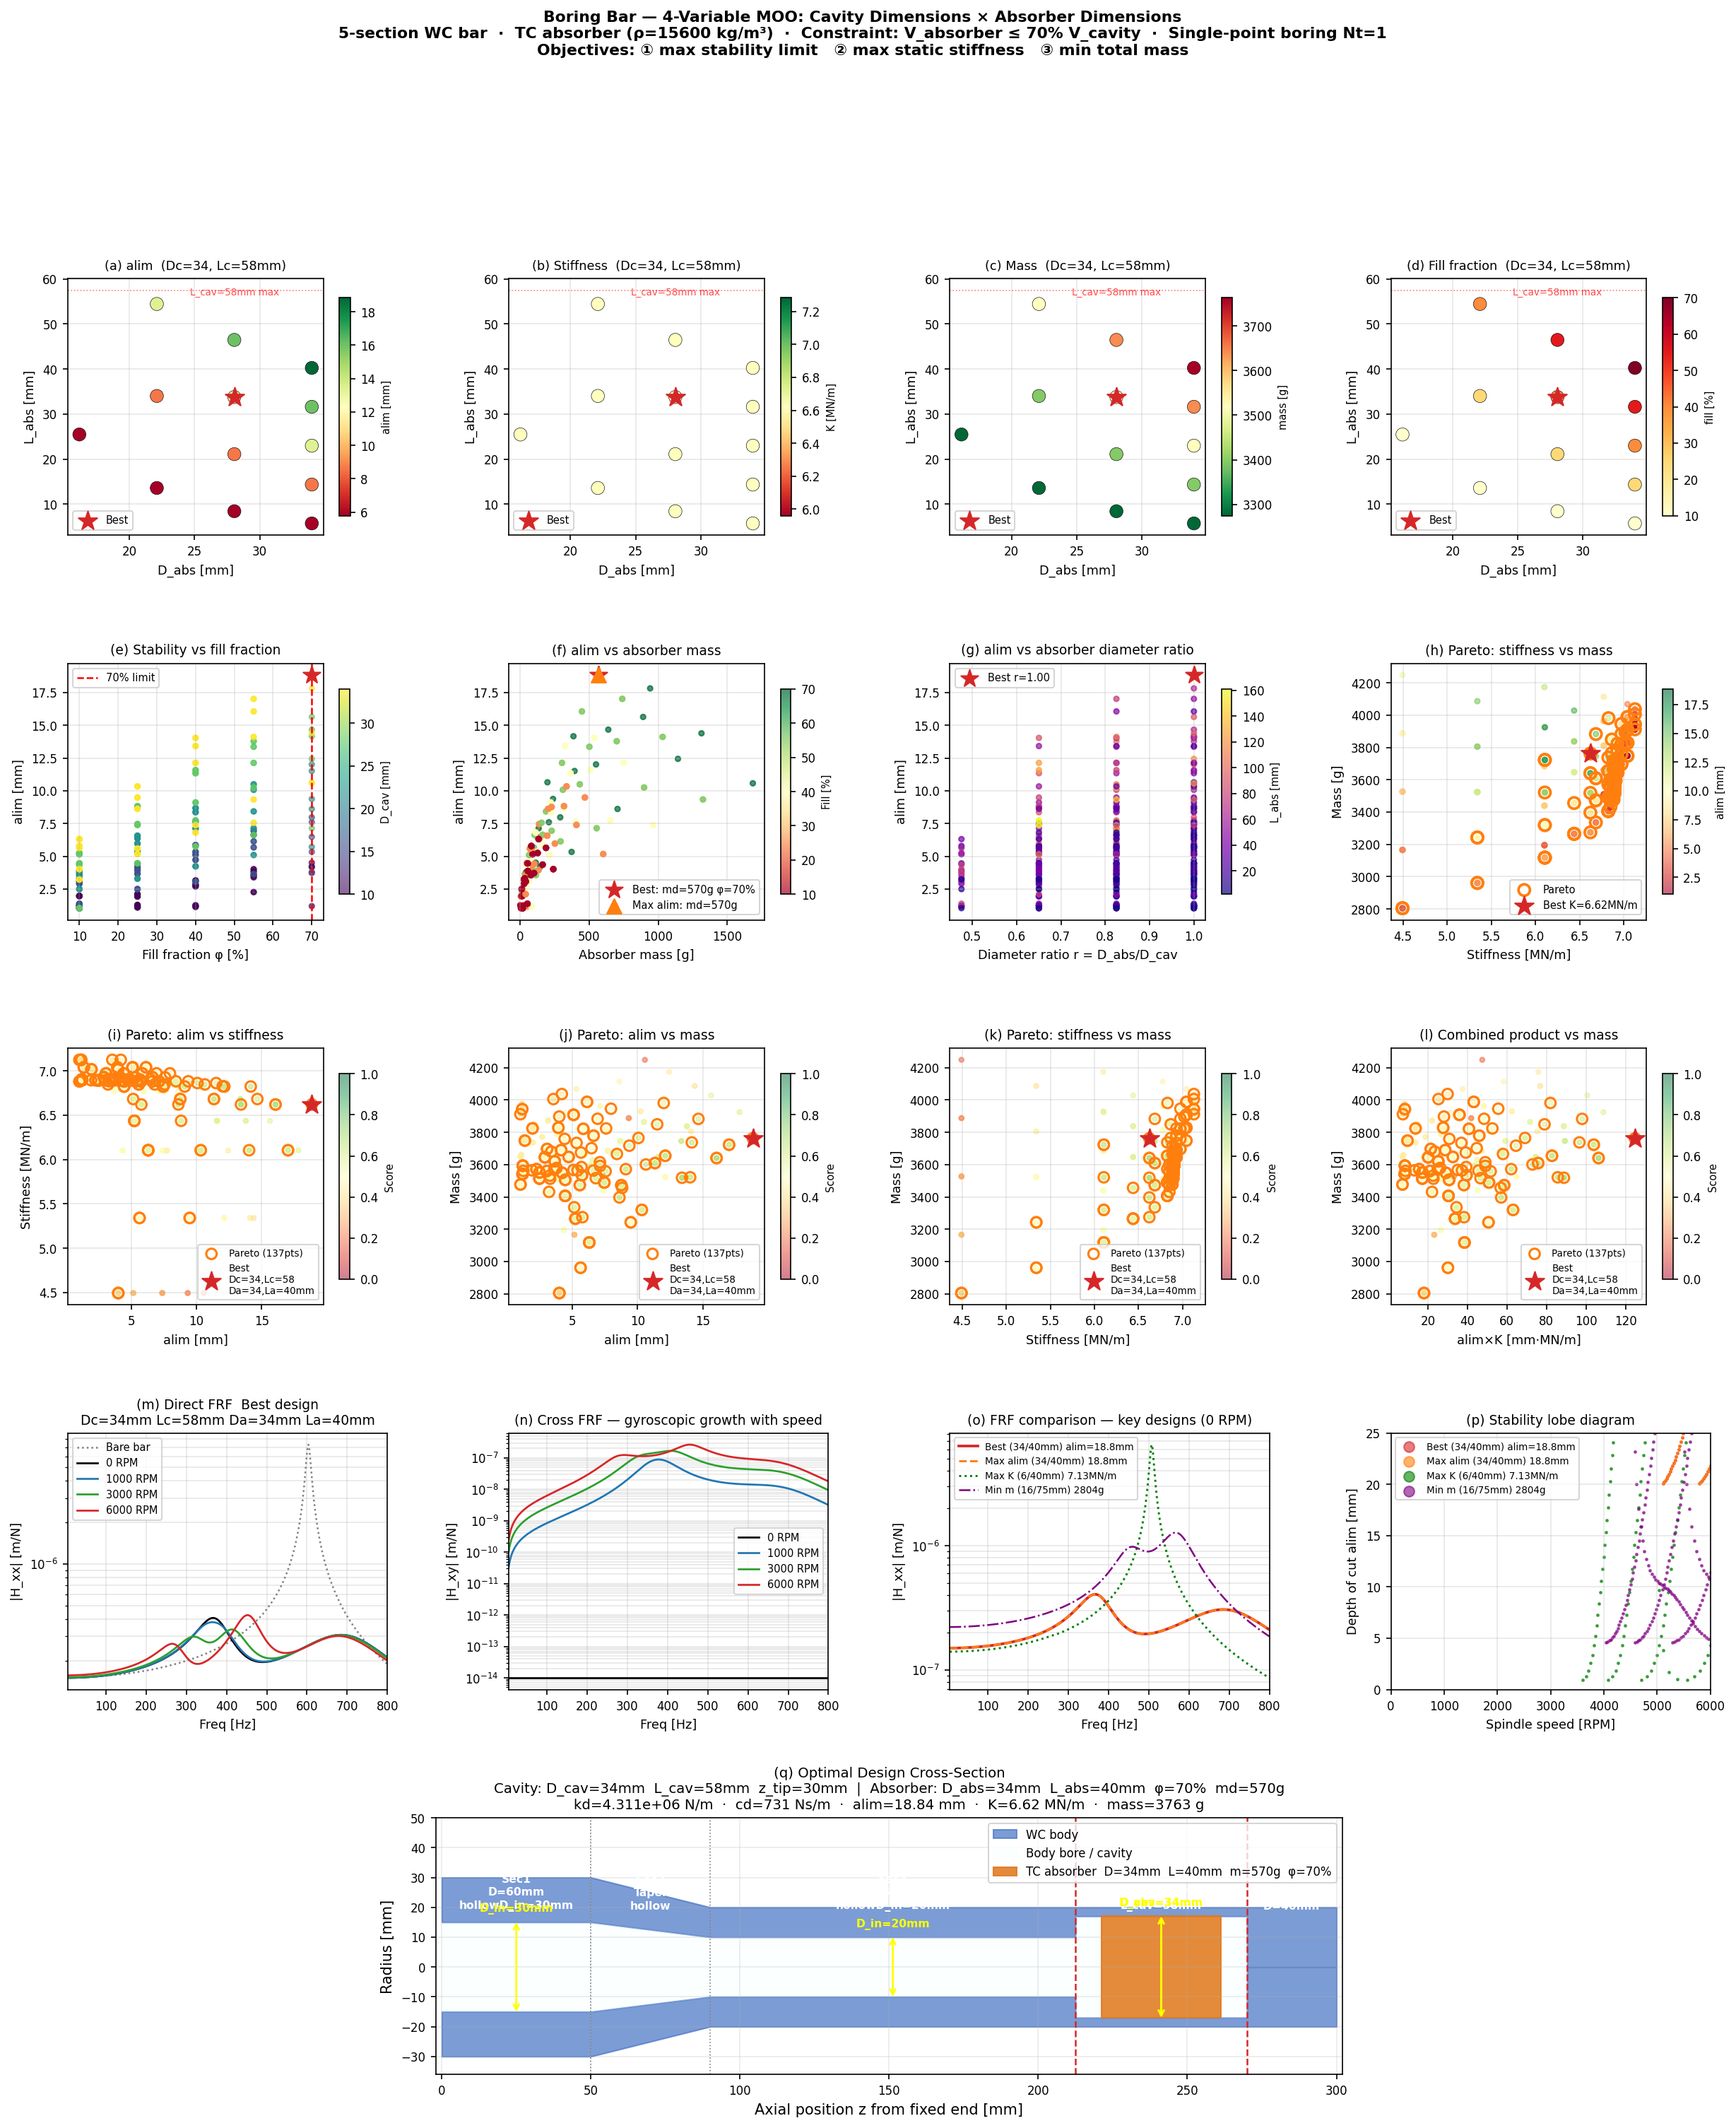


Figure saved → boring_bar_absorber_MOO.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# 14. PLOTS  (5 rows × 4 cols)
# ══════════════════════════════════════════════════════════════
BEST_C='#D62728'; PARETO_C='#FF7F0E'; NORM_C='#1F77B4'
fig = plt.figure(figsize=(20,22))
fig.suptitle(
    'Boring Bar — 4-Variable MOO: Cavity Dimensions × Absorber Dimensions\n'
    '5-section WC bar  ·  TC absorber (ρ=15600 kg/m³)  ·  '
    f'Constraint: V_absorber ≤ {VOL_FRAC_MAX*100:.0f}% V_cavity  ·  '
    'Single-point boring Nt=1\n'
    'Objectives: ① max stability limit   ② max static stiffness   ③ min total mass',
    fontsize=10.5, fontweight='bold', y=0.995)
gs = gridspec.GridSpec(5,4, figure=fig, hspace=0.50, wspace=0.38)

# ── ROW 0 ── Objective surfaces vs absorber dims (at best cavity) ──
# Filter to best cavity (Dc,Lc) = (Dc_v[i_best], Lc_v[i_best])
Dc_b=Dc_v[i_best]; Lc_b=Lc_v[i_best]
mask_cav = (np.abs(Dc_v-Dc_b)<0.5)&(np.abs(Lc_v-Lc_b)<0.5)
Da_bc=Da_v[mask_cav]; La_bc=La_v[mask_cav]
al_bc=a_v[mask_cav]; st_bc=s_v[mask_cav]; ms_bc=m_v[mask_cav]
vf_bc=vf_v[mask_cav]

for col,(ydata,clabel,ttl,cmap) in enumerate([
    (al_bc, 'alim [mm]',    f'(a) alim  (Dc={Dc_b:.0f}, Lc={Lc_b:.0f}mm)', 'RdYlGn'),
    (st_bc, 'K [MN/m]',     f'(b) Stiffness  (Dc={Dc_b:.0f}, Lc={Lc_b:.0f}mm)', 'RdYlGn'),
    (ms_bc, 'mass [g]',     f'(c) Mass  (Dc={Dc_b:.0f}, Lc={Lc_b:.0f}mm)', 'RdYlGn_r'),
    (vf_bc*100,'fill [%]',  f'(d) Fill fraction  (Dc={Dc_b:.0f}, Lc={Lc_b:.0f}mm)', 'YlOrRd'),
]):
    ax=fig.add_subplot(gs[0,col])
    sc=ax.scatter(Da_bc,La_bc,c=ydata,cmap=cmap,s=80,zorder=3,
                  vmin=ydata.min(),vmax=ydata.max(),edgecolors='k',lw=0.3)
    plt.colorbar(sc,ax=ax,shrink=0.85).set_label(clabel,fontsize=7)
    if len(al_bc)>0:
        best_in_cav = np.argmax((n01(al_bc)+n01(st_bc)+n01(-ms_bc))/3)
        ax.scatter(Da_bc[best_in_cav],La_bc[best_in_cav],s=180,
                   marker='*',color=BEST_C,zorder=5,label='Best')
    ax.set_xlabel('D_abs [mm]'); ax.set_ylabel('L_abs [mm]')
    ax.set_title(ttl,fontsize=8.5); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
    # Mark fill constraint boundary
    ax.axhline(Lc_b,color='red',ls=':',lw=0.8,alpha=0.5)
    ax.text(Da_bc.mean() if len(Da_bc)>0 else 10, Lc_b*0.98,
            f'L_cav={Lc_b:.0f}mm max',ha='center',fontsize=6.5,color='red',alpha=0.7)

# ── ROW 1 ── Effect of fill fraction on all objectives ────────
# (e) alim vs fill fraction — all cavity sizes
ax=fig.add_subplot(gs[1,0])
sc=ax.scatter(vf_v*100,a_v,c=Dc_v,cmap='viridis',s=12,alpha=0.6)
plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
ax.axvline(VOL_FRAC_MAX*100,color='red',ls='--',lw=1.2,label=f'{VOL_FRAC_MAX*100:.0f}% limit')
ax.scatter(vf_v[i_best]*100,a_v[i_best],s=150,marker='*',color=BEST_C,zorder=5)
ax.set_xlabel('Fill fraction φ [%]'); ax.set_ylabel('alim [mm]')
ax.set_title('(e) Stability vs fill fraction'); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

# (f) alim vs absorber mass — coloured by fill fraction
ax=fig.add_subplot(gs[1,1])
sc=ax.scatter(md_v,a_v,c=vf_v*100,cmap='RdYlGn',s=12,alpha=0.7,vmin=10,vmax=70)
plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Fill [%]',fontsize=7)
ax.scatter(md_v[i_best],a_v[i_best],s=150,marker='*',color=BEST_C,zorder=5,
           label=f'Best: md={md_v[i_best]:.0f}g φ={vf_v[i_best]*100:.0f}%')
ax.scatter(md_v[i_alim],a_v[i_alim],s=100,marker='^',color=PARETO_C,zorder=5,
           label=f'Max alim: md={md_v[i_alim]:.0f}g')
ax.set_xlabel('Absorber mass [g]'); ax.set_ylabel('alim [mm]')
ax.set_title('(f) alim vs absorber mass'); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

# (g) D_abs/D_cav ratio effect on alim
ax=fig.add_subplot(gs[1,2])
sc=ax.scatter(Da_v/Dc_v,a_v,c=La_v,cmap='plasma',s=12,alpha=0.7)
plt.colorbar(sc,ax=ax,shrink=0.8).set_label('L_abs [mm]',fontsize=7)
ax.scatter(Da_v[i_best]/Dc_v[i_best],a_v[i_best],s=150,marker='*',
           color=BEST_C,zorder=5,label=f'Best r={Da_v[i_best]/Dc_v[i_best]:.2f}')
ax.set_xlabel('Diameter ratio r = D_abs/D_cav'); ax.set_ylabel('alim [mm]')
ax.set_title('(g) alim vs absorber diameter ratio'); ax.legend(fontsize=7)
ax.grid(True,alpha=0.3)

# (h) stiffness vs mass (Pareto projection)
ax=fig.add_subplot(gs[1,3])
sc=ax.scatter(s_v,m_v,c=a_v,cmap='RdYlGn',s=12,alpha=0.6,
              vmin=a_v.min(),vmax=a_v.max())
plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
ax.scatter(s_v[pareto],m_v[pareto],s=60,edgecolors=PARETO_C,
           facecolors='none',lw=1.8,zorder=4,label='Pareto')
ax.scatter(s_v[i_best],m_v[i_best],s=180,marker='*',color=BEST_C,zorder=5,
           label=f'Best K={s_v[i_best]:.2f}MN/m')
ax.set_xlabel('Stiffness [MN/m]'); ax.set_ylabel('Mass [g]')
ax.set_title('(h) Pareto: stiffness vs mass'); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

# ── ROW 2 ── Pareto projections ───────────────────────────────
for col,(xa,ya,xl,yl,ttl) in enumerate([
    (a_v, s_v, 'alim [mm]',        'Stiffness [MN/m]', '(i) Pareto: alim vs stiffness'),
    (a_v, m_v, 'alim [mm]',        'Mass [g]',          '(j) Pareto: alim vs mass'),
    (s_v, m_v, 'Stiffness [MN/m]', 'Mass [g]',          '(k) Pareto: stiffness vs mass'),
    (a_v*s_v,  m_v, 'alim×K [mm·MN/m]','Mass [g]',     '(l) Combined product vs mass'),
]):
    ax=fig.add_subplot(gs[2,col])
    sc=ax.scatter(xa,ya,c=score,cmap='RdYlGn',s=10,alpha=0.5,vmin=0,vmax=1)
    ax.scatter(xa[pareto],ya[pareto],s=50,edgecolors=PARETO_C,
               facecolors='none',lw=1.5,zorder=4,label=f'Pareto ({pareto.sum()}pts)')
    ax.scatter(xa[i_best],ya[i_best],s=180,marker='*',c=BEST_C,zorder=5,
               label=f'Best\nDc={Dc_v[i_best]:.0f},Lc={Lc_v[i_best]:.0f}\n'
                     f'Da={Da_v[i_best]:.0f},La={La_v[i_best]:.0f}mm')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Score',fontsize=7)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.legend(fontsize=6.5); ax.grid(True,alpha=0.3)

# ── ROW 3 ── FRF + Stability lobes ───────────────────────────
best_r  = results[i_best]
Dc_b_m  = best_r['Dc']; Lc_b_m = best_r['Lc']
Da_b_m  = best_r['Da']; La_b_m = best_r['La']
kd_b    = best_r['kd']; cd_b   = best_r['cd']
modal_b = best_r['modal']
freqs_frf_plot=np.linspace(5,800,500)
speeds_frf=[0,1000,3000,6000]; clrs_frf=['k','#1F77B4','#2CA02C','#D62728']

# (m) Direct FRF: bare vs absorber, multiple speeds
ax=fig.add_subplot(gs[3,0])
Hno,_=frf(modal_b,freqs_frf_plot,0,Dc_b_m,Lc_b_m,Da_b_m,La_b_m,0,0)
ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hno),1e-14,None),
            color='gray',lw=1.2,ls=':',label='Bare bar')
for rpm,c in zip(speeds_frf,clrs_frf):
    Hw,_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,
             Dc_b_m,Lc_b_m,Da_b_m,La_b_m,kd_b,cd_b)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                color=c,lw=1.3,label=f'{rpm} RPM')
ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
ax.set_title(f'(m) Direct FRF  Best design\n'
             f'Dc={Dc_v[i_best]:.0f}mm Lc={Lc_v[i_best]:.0f}mm '
             f'Da={Da_v[i_best]:.0f}mm La={La_v[i_best]:.0f}mm')
ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

# (n) Cross FRF
ax=fig.add_subplot(gs[3,1])
for rpm,c in zip(speeds_frf,clrs_frf):
    _,Hxy_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,
               Dc_b_m,Lc_b_m,Da_b_m,La_b_m,kd_b,cd_b)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hxy_),1e-14,None),
                color=c,lw=1.3,label=f'{rpm} RPM')
ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xy| [m/N]')
ax.set_title('(n) Cross FRF — gyroscopic growth with speed')
ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

# (o) FRF comparison: 4 key designs
ax=fig.add_subplot(gs[3,2])
compare_cases=[(i_best, BEST_C,   '-',  1.8,
                f'Best ({Da_v[i_best]:.0f}/{La_v[i_best]:.0f}mm) alim={a_v[i_best]:.1f}mm'),
               (i_alim, PARETO_C, '--', 1.4,
                f'Max alim ({Da_v[i_alim]:.0f}/{La_v[i_alim]:.0f}mm) {a_v[i_alim]:.1f}mm'),
               (i_stiff,'green',  ':',  1.4,
                f'Max K ({Da_v[i_stiff]:.0f}/{La_v[i_stiff]:.0f}mm) {s_v[i_stiff]:.2f}MN/m'),
               (i_mass, 'purple', '-.', 1.2,
                f'Min m ({Da_v[i_mass]:.0f}/{La_v[i_mass]:.0f}mm) {m_v[i_mass]:.0f}g')]
for bidx,c,ls,lw_,lbl in compare_cases:
    r_=results[bidx]
    mo_=r_['modal']
    Hw,_=frf(mo_,freqs_frf_plot,0,r_['Dc'],r_['Lc'],r_['Da'],r_['La'],r_['kd'],r_['cd'])
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                color=c,lw=lw_,ls=ls,label=lbl)
ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
ax.set_title('(o) FRF comparison — key designs (0 RPM)')
ax.legend(fontsize=6.5); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

# (p) Stability lobe diagram
ax=fig.add_subplot(gs[3,3])
lobe_cases=compare_cases
for bidx,c,ls,lw_,lbl in lobe_cases:
    r_=results[bidx]
    sp,dp=stability_lobes(r_['modal'],r_['Dc'],r_['Lc'],r_['Da'],r_['La'],r_['kd'],r_['cd'])
    if len(sp):
        mk={'Best':'o','Max':'v','Min':'^','Wor':'x'}
        ax.scatter(sp,dp,s=2,c=c,alpha=0.6,label=lbl[:30])
ax.set_xlim(0,6000); ax.set_ylim(0,25)
ax.set_xlabel('Spindle speed [RPM]'); ax.set_ylabel('Depth of cut alim [mm]')
ax.set_title('(p) Stability lobe diagram')
ax.legend(markerscale=5,fontsize=6.5); ax.grid(True,alpha=0.3)

# ── ROW 4 ── Cross-section drawing of optimal design ──────────
ax=fig.add_subplot(gs[4,:])
zz=np.linspace(0,L_total,4000)
z2_=L1+L2; z_cav_=L_total-Z_TIP-Lc_b_m; z4_=z_cav_+Lc_b_m
Ro_p=[]; Ri_p=[]
for zp in zz:
    if zp<L1: Ro=D1_out/2
    elif zp<z2_: Ro=D1_out/2+(zp-L1)/L2*(D_main-D1_out)/2
    else: Ro=D_main/2
    if zp<L1: Ri=D_body_in1/2
    elif zp<z2_: t=(zp-L1)/L2; Ri=D_body_in1/2+t*(D_body_in3/2-D_body_in1/2)
    elif zp<z_cav_: Ri=D_body_in3/2
    elif zp<z4_: Ri=Dc_b_m/2
    else: Ri=0.0
    Ri=np.clip(Ri,0,Ro-1e-4)
    Ro_p.append(Ro*1e3); Ri_p.append(Ri*1e3)
Ro_p=np.array(Ro_p); Ri_p=np.array(Ri_p)

ax.fill_between(zz*1e3, Ri_p,  Ro_p,  alpha=0.70, color='#4472C4', label='WC body')
ax.fill_between(zz*1e3,-Ro_p, -Ri_p,  alpha=0.70, color='#4472C4')
ax.fill_between(zz*1e3, Ri_p, -Ri_p,  alpha=0.10, color='lightcyan', label='Body bore / cavity')

# Absorber block (centred in cavity, D_abs × L_abs)
abs_start = z_cav_ + (Lc_b_m - La_b_m)/2   # centred axially
abs_end   = abs_start + La_b_m
R_abs_plot= Da_b_m/2*1e3
ax.fill_betweenx([-R_abs_plot, R_abs_plot], abs_start*1e3, abs_end*1e3,
                  alpha=0.88, color='#E07B20',
                  label=f'TC absorber  D={Da_v[i_best]:.0f}mm  L={La_v[i_best]:.0f}mm  '
                        f'm={md_v[i_best]:.0f}g  φ={vf_v[i_best]*100:.0f}%')

# Cavity outline
ax.axvline(z_cav_*1e3, color=BEST_C,ls='--',lw=1.2)
ax.axvline(z4_*1e3,    color=BEST_C,ls='--',lw=1.2)
for xv in [L1*1e3,z2_*1e3]: ax.axvline(xv,color='gray',ls=':',lw=0.8)

# Section labels
sec_lbs=[(L1/2*1e3,'Sec1\nD=60mm\nhollowD_in=30mm'),
         ((L1+L2/2)*1e3,'Sec2\nTaper\nhollow'),
         ((z2_+(z_cav_-z2_)/2)*1e3,'Sec3\nD=40mm\nhollowD_in=20mm'),
         ((z_cav_+Lc_b_m/2)*1e3,'Sec4 — Cavity\n'
          f'D_cav={Dc_v[i_best]:.0f}mm\nL_cav={Lc_v[i_best]:.0f}mm'),
         ((z4_+(L_total-z4_)/2)*1e3,'Sec5\nSolid\nD=40mm')]
for xv,lbl in sec_lbs:
    ax.text(xv, Ro_p[0]*0.62, lbl, ha='center', va='bottom',
            fontsize=7.5, color='white', fontweight='bold', linespacing=1.3)

# Dimension annotations (yellow arrows)
dim_anns = [
    (L1/2*1e3,    D_body_in1/2*1e3, f'D_in={D_body_in1*1e3:.0f}mm'),
    ((z2_+(z_cav_-z2_)/2)*1e3, D_body_in3/2*1e3, f'D_in={D_body_in3*1e3:.0f}mm'),
    ((z_cav_+Lc_b_m/2)*1e3,    Dc_b_m/2*1e3,    f'D_cav={Dc_v[i_best]:.0f}mm'),
    ((abs_start+La_b_m/2)*1e3, Da_b_m/2*1e3,    f'D_abs={Da_v[i_best]:.0f}mm'),
]
for xv,yv,lbl in dim_anns:
    ax.annotate('',xy=(xv,yv+1),xytext=(xv,-yv-1),
                arrowprops=dict(arrowstyle='<->',color='yellow',lw=1.3))
    ax.text(xv,yv+3.5,lbl,ha='center',fontsize=7.5,color='yellow',fontweight='bold')

ax.set_xlim(-2,L_total*1e3+2); ax.set_ylim(-36,50)
ax.set_xlabel('Axial position z from fixed end [mm]',fontsize=10)
ax.set_ylabel('Radius [mm]',fontsize=10)
ax.set_title(
    f'(q) Optimal Design Cross-Section\n'
    f'Cavity: D_cav={Dc_v[i_best]:.0f}mm  L_cav={Lc_v[i_best]:.0f}mm  '
    f'z_tip=30mm  |  '
    f'Absorber: D_abs={Da_v[i_best]:.0f}mm  L_abs={La_v[i_best]:.0f}mm  '
    f'φ={vf_v[i_best]*100:.0f}%  md={md_v[i_best]:.0f}g\n'
    f'kd={kd_v[i_best]:.3e} N/m  ·  cd={cd_v[i_best]:.0f} Ns/m  ·  '
    f'alim={a_v[i_best]:.2f} mm  ·  K={s_v[i_best]:.2f} MN/m  ·  '
    f'mass={m_v[i_best]:.0f} g',
    fontsize=9.5)
ax.legend(fontsize=8,loc='upper right'); ax.grid(True,alpha=0.25)
ax.set_aspect('equal', adjustable='box')

plt.show()
print("\nFigure saved → boring_bar_absorber_MOO.png")